## 1. Introduction

### 1.1. 5 примеров применения ML в жизни и их преимущества

1. **Прогнозирование стоимости аренды квартиры**  
   Машинное обучение может одновременно анализировать большое количество объявлений, учитывать разные признаки квартиры и находить закономерности, которые сложно заметить вручную. Это помогает быстрее и точнее оценивать рыночную стоимость аренды.

2. **Определение спама в электронной почте**  
   ML-модель может автоматически анализировать текст письма, ссылки, отправителя и другие признаки, чтобы определить, является ли письмо спамом. Это экономит время пользователя и снижает риск фишинга или мошенничества.

3. **Поддержка медицинской диагностики**  
   Машинное обучение помогает врачам находить скрытые закономерности в медицинских данных: анализах, симптомах, снимках и истории болезни. Это может повысить точность диагностики и помочь быстрее принять решение.

4. **Сегментация клиентов**  
   ML может группировать клиентов на основе их поведения, истории покупок и предпочтений. Благодаря этому компании лучше понимают разные группы клиентов и могут делать для них более релевантные предложения.

5. **Система рекомендаций товаров**  
   Рекомендательные системы помогают пользователям быстрее находить подходящие товары или контент. Для компаний это повышает продажи, вовлечённость и удобство сервиса.

### 1.2. Классы задач для моих примеров

| Пример | Класс задачи | Почему |
|---|---|---|
| Прогнозирование стоимости аренды квартиры | Регрессия | Нужно предсказать числовое значение цены. |
| Определение спама | Бинарная классификация | Есть два класса: спам / не спам. |
| Медицинская диагностика | Классификация | Обычно нужно определить класс заболевания. Если прогнозируется числовой риск, это может быть регрессия. |
| Сегментация клиентов | Кластеризация | Нужно найти группы похожих клиентов без заранее заданных меток. |
| Рекомендации товаров | Рекомендации / ранжирование | Внутри могут использоваться классификация, регрессия, кластеризация и association rules. |

### 1.3. Классы задач из таблицы во введении

| № | Задача | Возможный класс ML-задачи |
|---:|---|---|
| 1 | Прогнозирование цен на жилье | Регрессия |
| 2 | Спрогнозируйте, вернет ли клиент кредит | Бинарная классификация |
| 3 | Спрогнозировать, когда пациенту потребуется принять лекарство. | Классификация или регрессия, зависит от формулировки: нужен препарат сейчас / через сколько времени он понадобится |
| 4 | Выберите, какое из доступных лекарств должен принимать пациент | Мультиклассовая классификация или рекомендательная задача |
| 5 | Выберите сегмент клиентов для рекламной кампании | Кластеризация, а также классификация/регрессия при прогнозе отклика или прибыли |
| 6 | Выявление дефектной продукции на производственной линии (на основе фотосканирования) | Бинарная классификация |
| 7 | Определите, как разместить товары на полках в магазине | Задача оптимизации; может использовать регрессию для прогноза продаж или ассоциативные правила |
| 8 | Поиск сайтов по запросу с использованием текстового ввода | Ранжирование / информационный поиск |
| 9 | Разделите покупателей магазина на сегменты, чтобы понять различия в их поведении | Кластеризация |
| 10 | Выявление аномалий в трафике сайта | Поиск аномалий, часто unsupervised learning |

Вывод: не все реальные задачи идеально попадают только в одну категорию. В зависимости от постановки одна и та же бизнес-задача может быть сформулирована как классификация, регрессия, кластеризация или рекомендательная задача.

### 1.4. Multiclass vs Multilabel

**Multiclass classification** — объект относится только к одному классу из нескольких возможных.  
Пример: уровень интереса к объявлению может быть только одним из вариантов: `high`, `medium` или `low`.

**Multilabel classification** — объект может одновременно принадлежать к нескольким классам.  
Пример: на фотографии могут одновременно быть метки `cat`, `dog` и `person`.

### 1.5. Цены квартир: регрессия или классификация?

Задача прогнозирования цены квартиры является задачей **регрессии**, потому что цена — это числовое значение.

Но её можно свести к **классификации**, если заранее разделить цены на категории, например: `дешёвая`, `средняя`, `дорогая`. В таком случае модель будет предсказывать не точную цену, а класс ценовой категории.

## 2. Introduction to Data Analysis

### 2.1. Импорт библиотек

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", "{:.6f}".format)

### 2.2. Загрузка данных

In [2]:
df = pd.read_json('data/train.json')
df.head()

,bathrooms,bedrooms,building_id,created,description,display_address,features,latitude,listing_id,longitude,manager_id,photos,price,street_address,interest_level
4,1.000000,1,8579a0b0d54db803821a35a4a615e97a,2016-06-16 05:55:27,Spacious 1 Bedroom 1 Bathroom in Williamsburg!...,145 Borinquen Place,"[Dining Room, Pre-War, Laundry in Building, Di...",40.710800,7170325,-73.953900,a10db4590843d78c784171a107bdacb4,[https://photos.renthop.com/2/7170325_3bb5ac84...,2400,145 Borinquen Place,medium
6,1.000000,2,b8e75fc949a6cd8225b455648a951712,2016-06-01 05:44:33,BRAND NEW GUT RENOVATED TRUE 2 BEDROOMFind you...,East 44th,"[Doorman, Elevator, Laundry in Building, Dishw...",40.751300,7092344,-73.972200,955db33477af4f40004820b4aed804a0,[https://photos.renthop.com/2/7092344_7663c19a...,3800,230 East 44th,low
9,1.000000,2,cd759a988b8f23924b5a2058d5ab2b49,2016-06-14 15:19:59,**FLEX 2 BEDROOM WITH FULL PRESSURIZED WALL**L...,East 56th Street,"[Doorman, Elevator, Laundry in Building, Laund...",40.757500,7158677,-73.962500,c8b10a317b766204f08e613cef4ce7a0,[https://photos.renthop.com/2/7158677_c897a134...,3495,405 East 56th Street,medium
10,1.500000,3,53a5b119ba8f7b61d4e010512e0dfc85,2016-06-24 07:54:24,A Brand New 3 Bedroom 1.5 bath ApartmentEnjoy ...,Metropolitan Avenue,[],40.714500,7211212,-73.942500,5ba989232d0489da1b5f2c45f6688adc,[https://photos.renthop.com/2/7211212_1ed4542e...,3000,792 Metropolitan Avenue,medium
15,1.000000,0,bfb9405149bfff42a92980b594c28234,2016-06-28 03:50:23,Over-sized Studio w abundant closets. Availabl...,East 34th Street,"[Doorman, Elevator, Fitness Center, Laundry in...",40.743900,7225292,-73.974300,2c3b41f588fbb5234d8a1e885a436cfa,[https://photos.renthop.com/2/7225292_901f1984...,2795,340 East 34th Street,low


### 2.3. Размер данных

In [3]:
df.shape

(49352, 15)

В датасете **49 352 строки** и **15 столбцов**.

### 2.4. Список колонок и целевая переменная

In [4]:
columns = df.columns.tolist()
columns

['bathrooms',
 'bedrooms',
 'building_id',
 'created',
 'description',
 'display_address',
 'features',
 'latitude',
 'listing_id',
 'longitude',
 'manager_id',
 'photos',
 'price',
 'street_address',
 'interest_level']

Целевая переменная — `price`, потому что в проекте нужно предсказывать стоимость аренды квартиры.

### 2.5. Быстрый анализ данных: `info()`, `describe()`, `corr()`

In [5]:
df.info()

<class 'pandas.DataFrame'>
Index: 49352 entries, 4 to 124009
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   bathrooms        49352 non-null  float64
 1   bedrooms         49352 non-null  int64  
 2   building_id      49352 non-null  str    
 3   created          49352 non-null  str    
 4   description      49352 non-null  str    
 5   display_address  49352 non-null  str    
 6   features         49352 non-null  object 
 7   latitude         49352 non-null  float64
 8   listing_id       49352 non-null  int64  
 9   longitude        49352 non-null  float64
 10  manager_id       49352 non-null  str    
 11  photos           49352 non-null  object 
 12  price            49352 non-null  int64  
 13  street_address   49352 non-null  str    
 14  interest_level   49352 non-null  str    
dtypes: float64(3), int64(3), object(2), str(7)
memory usage: 6.0+ MB


In [6]:
df.describe()

,bathrooms,bedrooms,latitude,listing_id,longitude,price
count,49352.000000,49352.000000,49352.000000,49352.000000,49352.000000,49352.000000
mean,1.212180,1.541640,40.741545,7024054.655394,-73.955716,3830.174036
std,0.501420,1.115018,0.638535,126274.611244,1.177912,22066.865885
min,0.000000,0.000000,0.000000,6811957.000000,-118.271000,43.000000
25%,1.000000,1.000000,40.728300,6915887.500000,-73.991700,2500.000000
50%,1.000000,1.000000,40.751800,7021070.500000,-73.977900,3150.000000
75%,1.000000,2.000000,40.774300,7128733.250000,-73.954800,4100.000000
max,10.000000,8.000000,44.883500,7753784.000000,0.000000,4490000.000000


In [7]:
missing_values = df.isna().sum().sort_values(ascending=False)
missing_values

bathrooms          0
bedrooms           0
building_id        0
created            0
description        0
display_address    0
features           0
latitude           0
listing_id         0
longitude          0
manager_id         0
photos             0
price              0
street_address     0
interest_level     0
dtype: int64

Пропусков в формате `NaN` нет. При этом в некоторых текстовых/списочных полях могут встречаться пустые строки или пустые списки, но полностью пустых столбцов нет.

In [8]:
numeric_corr = df.select_dtypes(include=[np.number]).corr()
numeric_corr

,bathrooms,bedrooms,latitude,listing_id,longitude,price
bathrooms,1.000000,0.533446,-0.009657,0.000776,0.010393,0.069661
bedrooms,0.533446,1.000000,-0.004745,0.011968,0.006892,0.051788
latitude,-0.009657,-0.004745,1.000000,0.001712,-0.966807,-0.000707
listing_id,0.000776,0.011968,0.001712,1.000000,-0.000907,0.008090
longitude,0.010393,0.006892,-0.966807,-0.000907,1.000000,-0.000087
price,0.069661,0.051788,-0.000707,0.008090,-0.000087,1.000000


По исходной корреляционной матрице видно, что из-за сильных выбросов в `price` связь цены с числовыми признаками искажена.

### 2.6. Рабочий датафрейм с признаками `bathrooms`, `bedrooms`, `interest_level` и target `price`

In [9]:
data = df[["bathrooms", "bedrooms", "interest_level", "price"]].copy()
data.head()

,bathrooms,bedrooms,interest_level,price
4,1.000000,1,medium,2400
6,1.000000,2,low,3800
9,1.000000,2,medium,3495
10,1.500000,3,medium,3000
15,1.000000,0,low,2795


## 3. Statistical Data Analysis

### 3.1. Target analysis: распределение `price`

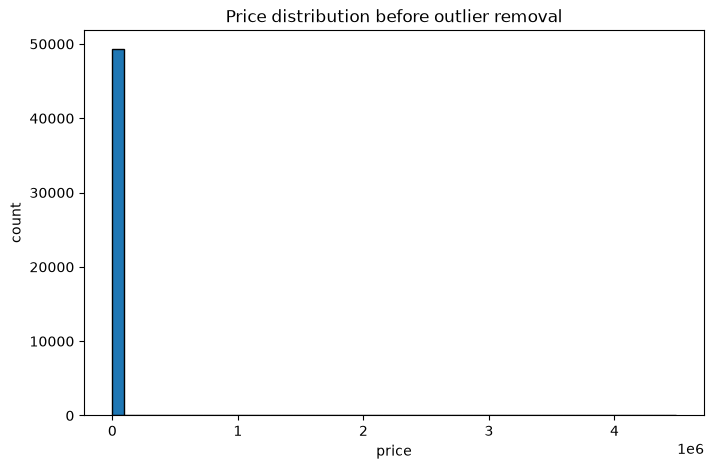

In [10]:
plt.figure(figsize=(8, 5))
plt.hist(data["price"], bins=50, edgecolor="black")
plt.title("Price distribution before outlier removal")
plt.xlabel("price")
plt.ylabel("count")
plt.show()

Гистограмма исходного `price` почти нечитаема: основная масса объявлений находится в низком ценовом диапазоне, но есть экстремально большие значения. Из-за таких выбросов масштаб графика сильно растягивается.

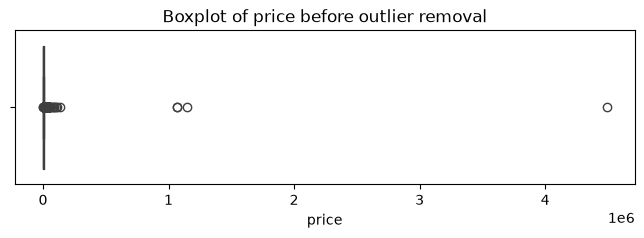

In [11]:
plt.figure(figsize=(8, 2))
sns.boxplot(x=data["price"])
plt.title("Boxplot of price before outlier removal")
plt.xlabel("price")
plt.show()

Boxplot подтверждает наличие сильных выбросов: встречаются цены, которые намного выше основной массы значений. Такие наблюдения могут сильно влиять на статистики и качество моделей.

### 3.2. Удаление строк вне 1-го и 99-го процентилей `price`

In [12]:
price_01 = data["price"].quantile(0.01)
price_99 = data["price"].quantile(0.99)
data_clean = data[(data["price"] > price_01) & (data["price"] < price_99)].copy()

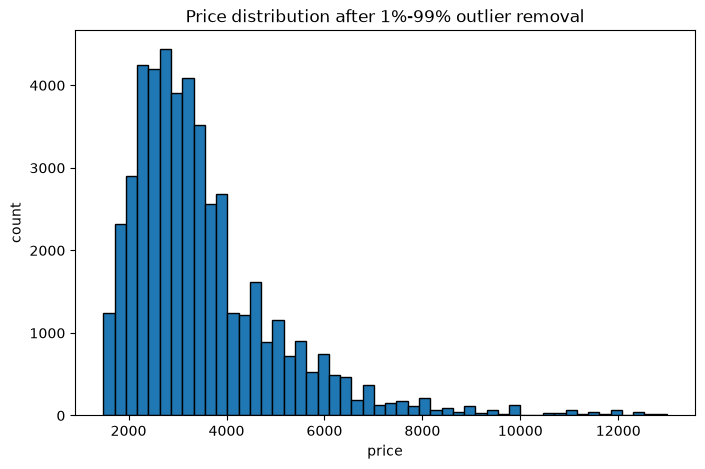

In [13]:
plt.figure(figsize=(8, 5))
plt.hist(data_clean["price"], bins=50, edgecolor="black")
plt.title("Price distribution after 1%-99% outlier removal")
plt.xlabel("price")
plt.ylabel("count")
plt.show()

После удаления экстремальных значений распределение стало намного понятнее. Большинство цен находится примерно в диапазоне от 1500 до 5000, но правый хвост всё ещё сохраняется: дорогих квартир меньше, но они есть.

### 3.3. Characteristics Analysis: `interest_level`

In [14]:
interest_counts = data_clean["interest_level"].value_counts()
interest_counts

interest_level
low       33672
medium    11114
high       3557
Name: count, dtype: int64

`interest_level` — категориальный признак типа `object`. В нём три значения: `low`, `medium`, `high`.

In [15]:
interest_map = {
    "low": 0,
    "medium": 1,
    "high": 2,
}

data_clean["interest_level"] = data_clean["interest_level"].map(interest_map)
data_clean.head()

,bathrooms,bedrooms,interest_level,price
4,1.000000,1,1,2400
6,1.000000,2,0,3800
9,1.000000,2,1,3495
10,1.500000,3,1,3000
15,1.000000,0,0,2795


### 3.4. Гистограммы признаков `bathrooms` и `bedrooms`

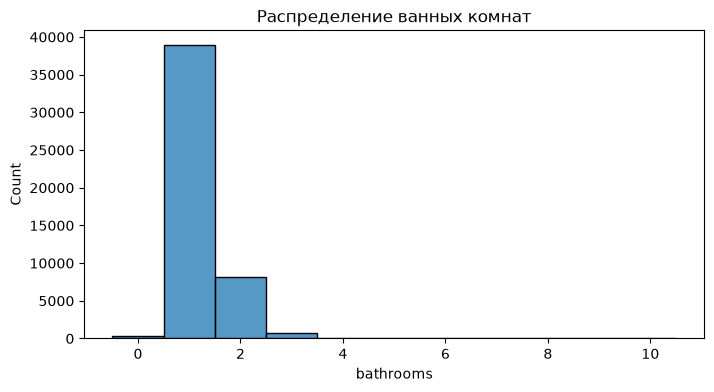

In [16]:
plt.figure(figsize=(8, 4))
sns.histplot(data=data_clean, x='bathrooms', discrete=True)
plt.title('Распределение ванных комнат')
plt.show()

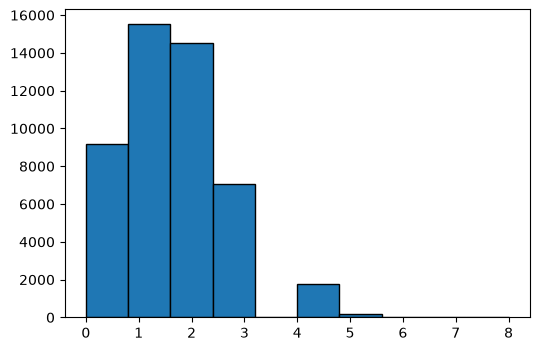

In [17]:
plt.figure(figsize=(6, 4))
plt.hist(data_clean.bedrooms, edgecolor='black')
plt.show()

`bathrooms` и `bedrooms` — дискретные числовые признаки. Большинство квартир имеет 1–2 ванные комнаты и 0–3 спальни. Значения вроде 5+ ванных или 6+ спален встречаются редко и могут рассматриваться как выбросы или необычные объекты.

### 3.5. Complex analysis: корреляционная матрица и heatmap

In [18]:
corr_matrix = data_clean.corr()
corr_matrix

,bathrooms,bedrooms,interest_level,price
bathrooms,1.000000,0.517200,-0.062819,0.670808
bedrooms,0.517200,1.000000,0.051282,0.547310
interest_level,-0.062819,0.051282,1.000000,-0.199652
price,0.670808,0.547310,-0.199652,1.000000


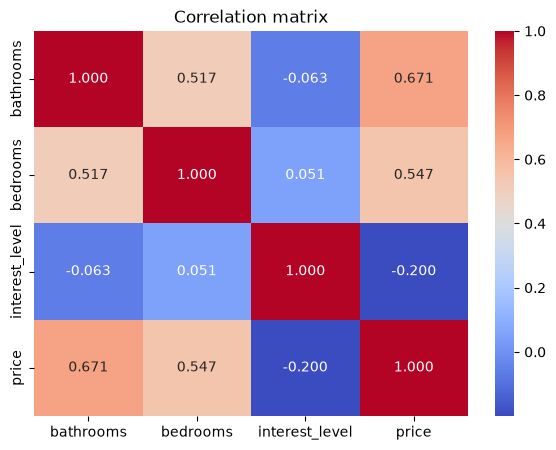

In [19]:
plt.figure(figsize=(7, 5))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".3f")
plt.title("Correlation matrix")
plt.show()

Вывод по корреляции:

- `bathrooms` имеет заметную положительную корреляцию с `price`.
- `bedrooms` тоже положительно связан с `price`, но немного слабее.
- `interest_level` имеет слабую отрицательную корреляцию с `price`: более высокий интерес чаще связан с более доступными объявлениями.

### 3.6. Scatterplot: связь признаков с `price`

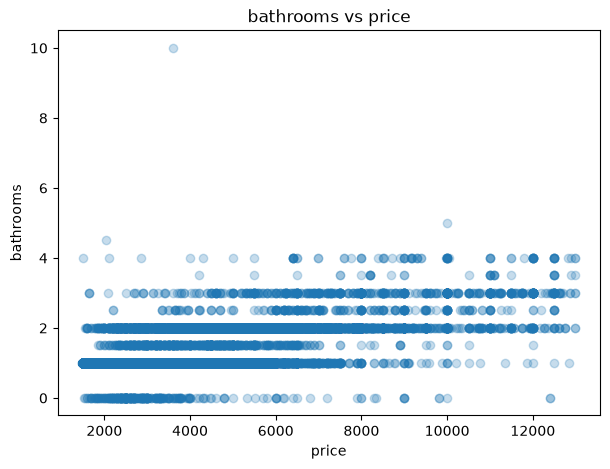

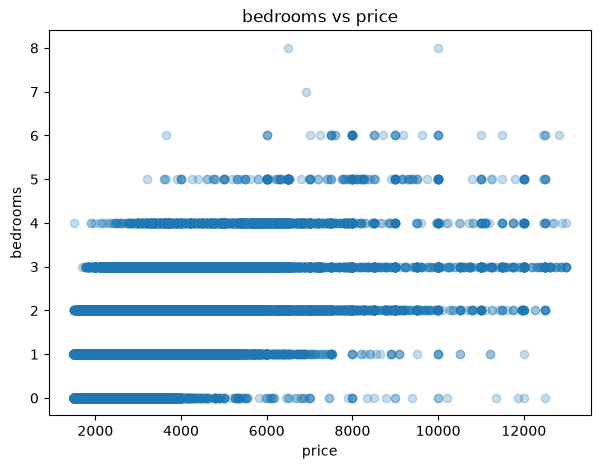

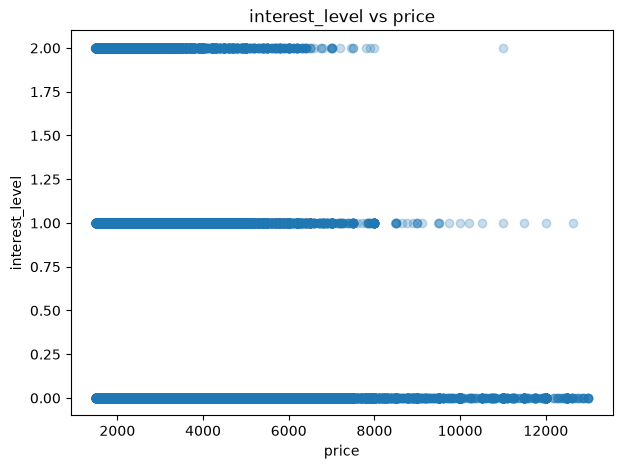

In [20]:
features_for_scatter = ["bathrooms", "bedrooms", "interest_level"]

for feature in features_for_scatter:
    plt.figure(figsize=(7, 5))
    plt.scatter(data_clean["price"], data_clean[feature], alpha=0.25)
    plt.title(f"{feature} vs price")
    plt.xlabel("price")
    plt.ylabel(feature)
    plt.show()

По scatterplot видно, что с ростом количества ванных комнат и спален цена в среднем растёт, но зависимость не является идеально линейной. Наблюдается большой разброс: квартиры с одинаковым количеством комнат могут иметь разную цену.

## 4. Creating Features

### 4.1. Создание квадратов признаков

In [21]:
data_features = data_clean.copy()

data_features["bathrooms_squared"] = data_features["bathrooms"] ** 2
data_features["bedrooms_squared"] = data_features["bedrooms"] ** 2
data_features["interest_level_squared"] = data_features["interest_level"] ** 2

data_features.head()

,bathrooms,bedrooms,interest_level,price,bathrooms_squared,bedrooms_squared,interest_level_squared
4,1.000000,1,1,2400,1.000000,1,1
6,1.000000,2,0,3800,1.000000,4,0
9,1.000000,2,1,3495,1.000000,4,1
10,1.500000,3,1,3000,2.250000,9,1
15,1.000000,0,0,2795,1.000000,0,0


In [22]:
corr_with_squares = data_features.corr()
corr_with_squares

,bathrooms,bedrooms,interest_level,price,bathrooms_squared,bedrooms_squared,interest_level_squared
bathrooms,1.000000,0.517200,-0.062819,0.670808,0.955906,0.548426,-0.058710
bedrooms,0.517200,1.000000,0.051282,0.547310,0.478497,0.928282,0.040125
interest_level,-0.062819,0.051282,1.000000,-0.199652,-0.067757,0.047048,0.943959
price,0.670808,0.547310,-0.199652,1.000000,0.646949,0.544612,-0.182283
bathrooms_squared,0.955906,0.478497,-0.067757,0.646949,1.000000,0.521951,-0.061563
bedrooms_squared,0.548426,0.928282,0.047048,0.544612,0.521951,1.000000,0.036408
interest_level_squared,-0.058710,0.040125,0.943959,-0.182283,-0.061563,0.036408,1.000000


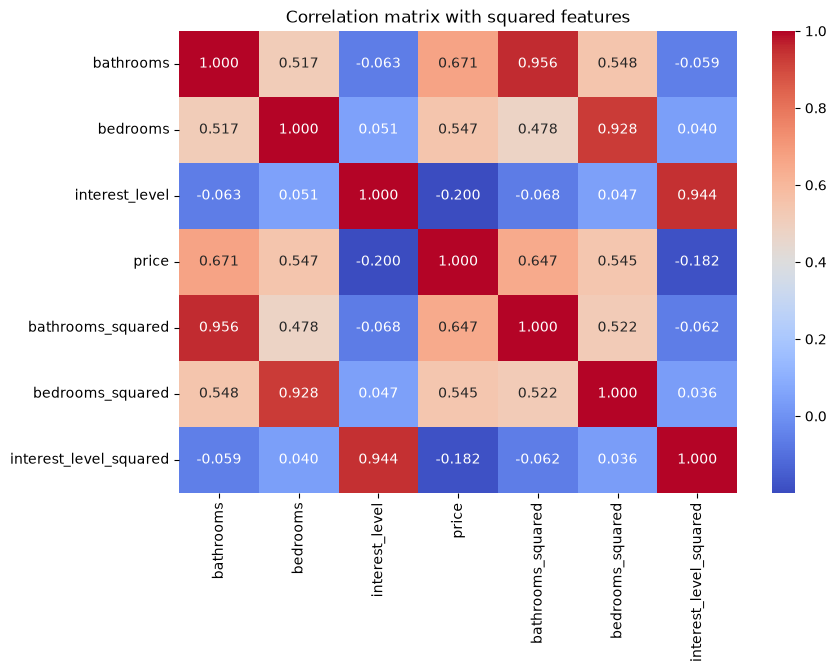

In [23]:
plt.figure(figsize=(9, 6))
sns.heatmap(corr_with_squares, annot=True, cmap="coolwarm", fmt=".3f")
plt.title("Correlation matrix with squared features")
plt.show()

Квадратные признаки не дали заметно более сильной связи с `price`:

- `bathrooms` коррелирует с `price` сильнее, чем `bathrooms_squared`;
- `bedrooms` и `bedrooms_squared` имеют почти одинаковую корреляцию с `price`;
- `interest_level_squared` не улучшает связь с целевой переменной по сравнению с обычным `interest_level`.

Значит, сами по себе эти квадратные признаки не выглядят существенно полезнее базовых признаков.

### 4.2. Split на train/test и PolynomialFeatures

Для воспроизведения проверочных результатов используем признаки `bathrooms`, `bedrooms`, `interest_level` после кодирования.  
Разделение: `test_size=0.25`, `random_state=21`

In [41]:
model_features = ["bathrooms", "bedrooms", "interest_level"]
X = data_clean[model_features]
y = data_clean["price"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=21,
)

In [42]:
poly = PolynomialFeatures(degree=10)

X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

## 5. Models

Нужно обучить 3 типа моделей:

1. Linear Regression;
2. Decision Tree Regressor;
3. Naive models: прогноз средним и медианой.

Для сравнения используем две метрики:

- **MAE** — Mean Absolute Error;
- **RMSE** — Root Mean Squared Error.

### 5.1. Подготовка таблиц результатов и вспомогательной функции

In [40]:
result_MAE = pd.DataFrame(columns=["model", "train", "test"])
result_RMSE = pd.DataFrame(columns=["model", "train", "test"])

train_result = X_train.copy()
train_result["price"] = y_train

test_result = X_test.copy()
test_result["price"] = y_test


def add_metrics(model_name, y_train_true, y_train_pred, y_test_true, y_test_pred):
    global result_MAE, result_RMSE
    
    train_mae = mean_absolute_error(y_train_true, y_train_pred)
    test_mae = mean_absolute_error(y_test_true, y_test_pred)
    
    train_rmse = mean_squared_error(y_train_true, y_train_pred) ** 0.5
    test_rmse = mean_squared_error(y_test_true, y_test_pred) ** 0.5
    
    result_MAE.loc[len(result_MAE)] = [model_name, train_mae, test_mae]
    result_RMSE.loc[len(result_RMSE)] = [model_name, train_rmse, test_rmse]

### 5.2. Linear Regression

In [35]:
linreg = LinearRegression()
linreg.fit(X_train_poly, y_train)

train_result["linreg_pred"] = linreg.predict(X_train_poly)
test_result["linreg_pred"] = linreg.predict(X_test_poly)

add_metrics(
    "linreg",
    y_train,
    train_result["linreg_pred"],
    y_test,
    test_result["linreg_pred"],
)

### 5.3. Decision Tree Regressor

In [36]:
tree = DecisionTreeRegressor(random_state=21)
tree.fit(X_train, y_train)

train_result["tree_pred"] = tree.predict(X_train)
test_result["tree_pred"] = tree.predict(X_test)

add_metrics(
    "tree",
    y_train,
    train_result["tree_pred"],
    y_test,
    test_result["tree_pred"],
)

### 5.4. Naive models: mean и median

In [37]:
train_price_mean = y_train.mean()
train_price_median = y_train.median()

print("Train mean price:", train_price_mean)
print("Train median price:", train_price_median)

train_result["mean_pred"] = train_price_mean
test_result["mean_pred"] = train_price_mean

train_result["median_pred"] = train_price_median
test_result["median_pred"] = train_price_median

add_metrics(
    "mean",
    y_train,
    train_result["mean_pred"],
    y_test,
    test_result["mean_pred"],
)

add_metrics(
    "median",
    y_train,
    train_result["median_pred"],
    y_test,
    test_result["median_pred"],
)

Train mean price: 3535.823783420386
Train median price: 3150.0


### 5.5. Итоговые таблицы метрик

In [38]:
result_MAE

,model,train,test
0,linreg,828.452318,852.494813
1,tree,718.825041,727.203892
2,mean,1131.815443,1145.424080
3,median,1079.734162,1092.167132


In [39]:
result_RMSE

,model,train,test
0,linreg,1177.257108,1841.759442
1,tree,1025.483464,1032.653779
2,mean,1580.460676,1606.037379
3,median,1626.873056,1650.964260


### 5.6. Сравнение моделей

По метрике **MAE** на тестовой выборке лучший результат показывает `tree`.

По метрике **RMSE** на тестовой выборке также лучший результат показывает `tree`.

`linreg` с PolynomialFeatures степени 10 сильно переобучается: на train-выборке ошибка получается низкой, но на test-выборке RMSE становится очень большим. Это означает, что модель плохо обобщает закономерности на новые данные.

Наивные модели `mean` и `median` хуже дерева, но полезны как baseline: они показывают минимальный уровень качества, с которым стоит сравнивать реальные ML-модели.

**Итоговый лучший вариант из этих моделей — `DecisionTreeRegressor`.**